In [100]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from tqdm import tqdm
from scipy.stats import gamma, truncnorm, lognorm, norm
from scipy.optimize import least_squares, minimize
from itertools import combinations

First fit duration distribution, which will help calibrate some of our moments.

In [45]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")
duration_data = final_allrisk_ds['duration']

In [46]:
TRUNC_YEARS = 10

In [47]:
class LogNormalBayesianUpdater:
    def __init__(self, prior_type='reference', mu0=0, kappa0=0.01, alpha0=1.1, beta0=1):
        """
        Initialize the Bayesian updater.
        
        prior_type: 'reference' or 'NIG' (Normal-Inverse-Gamma)
        mu0, kappa0, alpha0, beta0: Hyperparameters for NIG prior
        """
        if prior_type not in ['reference', 'NIG']:
            raise ValueError("prior_type must be either 'reference' or 'NIG'")
        self.prior_type = prior_type
        self.mu0 = mu0
        self.kappa0 = kappa0
        self.alpha0 = alpha0
        self.beta0 = beta0

    def update(self, X):
        """
        Update posterior given observed data X (lognormal data).
        """
        self.X = X
        self.Y = np.log(X)  # work on log scale
        self.n = len(X)
        self.y_bar = np.mean(self.Y)
        self.S = np.sum((self.Y - self.y_bar) ** 2)

        if self.prior_type == 'NIG':
            self.kappa_n = self.kappa0 + self.n
            self.mu_n = (self.kappa0 * self.mu0 + self.n * self.y_bar) / self.kappa_n
            self.alpha_n = self.alpha0 + self.n / 2
            self.beta_n = (self.beta0 + 0.5 * self.S + 
                           0.5 * self.kappa0 * self.n * (self.y_bar - self.mu0)**2 / self.kappa_n)
        elif self.prior_type == 'reference':
            self.kappa_n = self.n
            self.mu_n = self.y_bar
            self.alpha_n = (self.n - 1) / 2
            self.beta_n = self.S / 2
    
    def sample_prior(self, n_samples=1000, rng=None):
        """
        Sample (mu, sigma) from the prior distribution.
        
        Parameters
        ----------
        n_samples : int
            Number of samples to draw from the prior distribution
            
        Returns
        -------
        tuple
            (mu_samples, sigma_samples) drawn from the prior distribution.
            Returns None, None if using reference prior since it is improper.
        """
        if self.prior_type == 'reference':
            print("Reference prior is improper (only defined up to proportionality). Skipping prior samples.")
            return None, None
            
        sigma2_samples = scipy.stats.invgamma.rvs(a=self.alpha0, scale=self.beta0, size=n_samples, random_state=rng)
        mu_samples = scipy.stats.norm.rvs(loc=self.mu0, scale=np.sqrt(sigma2_samples / self.kappa0), random_state=rng)
        sigma_samples = np.sqrt(sigma2_samples)

        return mu_samples, sigma_samples

    def sample_posterior(self, n_samples=1000, rng=None):
        """
        Sample (mu, sigma) from the posterior distribution.
        """
        sigma2_samples = scipy.stats.invgamma.rvs(a=self.alpha_n, scale=self.beta_n, size=n_samples, random_state=rng)
        mu_samples = scipy.stats.norm.rvs(loc=self.mu_n, scale=np.sqrt(sigma2_samples / self.kappa_n), random_state=rng)
        sigma_samples = np.sqrt(sigma2_samples)

        return mu_samples, sigma_samples
   
    def get_prior_grid(self, mu_range=None, sigma_range=None, n_points=100):
        """
        Calculate the analytical prior probability density function on a grid.
        
        Parameters
        ----------
        mu_range : tuple, optional
            Range of mu values (min, max). If None, determined automatically.
        sigma_range : tuple, optional
            Range of sigma values (min, max). If None, determined automatically.
        n_points : int, optional
            Number of points to use in each dimension, by default 50
            
        Returns
        -------
        dict
            Dictionary containing grid points and density values:
            - 'mu_grid': 2D array of mu values
            - 'sigma_grid': 2D array of sigma values 
            - 'density': 2D array of density values
        """
        if self.prior_type == 'reference':
            print("Reference prior is improper. Cannot calculate analytical PDF.")
            return None
        
        # Generate grid of points
        if mu_range is None: # Three expected stds around mean
            mu_range = (self.mu0 - 3 * np.sqrt(self.beta0 / ((self.alpha0 - 1) * self.kappa0)), # 
                        self.mu0 + 3 * np.sqrt(self.beta0 / ((self.alpha0 - 1) * self.kappa0)))
        
        if sigma_range is None:
            mode_sigma = np.sqrt(self.beta0 / (self.alpha0 + 1))  # Mode of inverse gamma
            sigma_range = (mode_sigma / 3, mode_sigma * 3)
        
        mu_grid = np.linspace(*mu_range, n_points)
        sigma_grid = np.linspace(*sigma_range, n_points)
        MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
        
        # Calculate prior density
        SIGMA2 = SIGMA ** 2
        
        # p(mu, sigma²) = p(mu|sigma²) * p(sigma²)
        # p(mu|sigma²) = Normal(mu0, sigma²/kappa0)
        # p(sigma²) = InvGamma(alpha0, beta0)
        mu_density     = scipy.stats.norm.pdf(MU, loc=self.mu0, scale=np.sqrt(SIGMA2 / self.kappa0))
        sigma2_density = scipy.stats.invgamma.pdf(SIGMA2, a=self.alpha0, scale=self.beta0)
        density = 2 * SIGMA * mu_density * sigma2_density # Jacobian correction for σ² → σ
                
        return pd.DataFrame({
            'mu': MU.flatten(),
            'sigma': SIGMA.flatten(),
            'density': density.flatten()
        })

    def get_posterior_grid(self, mu_range=None, sigma_range=None, n_points=100):
        """
        Calculate the analytical posterior probability density function on a grid.
        
        Parameters
        ----------
        mu_range : tuple, optional
            Range of mu values (min, max). If None, determined automatically.
        sigma_range : tuple, optional
            Range of sigma values (min, max). If None, determined automatically.
        n_points : int, optional
            Number of points to use in each dimension, by default 50
            
        Returns
        -------
        dict
            Dictionary containing grid points and density values:
            - 'mu_grid': 2D array of mu values
            - 'sigma_grid': 2D array of sigma values
            - 'density': 2D array of density values
        """
        # Generate grid of points
        if mu_range is None:
            mu_range = (self.mu_n - 3 * np.sqrt(self.beta_n / ((self.alpha_n - 1) * self.kappa_n)), 
                        self.mu_n + 3 * np.sqrt(self.beta_n / ((self.alpha_n - 1) * self.kappa_n)))
        
        if sigma_range is None:
            mode_sigma = np.sqrt(self.beta_n / (self.alpha_n + 1))  # Mode of inverse gamma
            sigma_range = (mode_sigma / 3, mode_sigma * 3)
        
        mu_grid = np.linspace(mu_range[0], mu_range[1], n_points)
        sigma_grid = np.linspace(sigma_range[0], sigma_range[1], n_points)
        MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
        
        # Calculate posterior density
        SIGMA2 = SIGMA**2
        
        # p(mu, sigma²|data) = p(mu|sigma², data) * p(sigma²|data)
        # p(mu|sigma², data) = Normal(mu_n, sigma²/kappa_n)
        # p(sigma²|data) = InvGamma(alpha_n, beta_n)
        mu_density     = scipy.stats.norm.pdf(MU, loc=self.mu_n, scale=np.sqrt(SIGMA2 / self.kappa_n))
        sigma2_density = scipy.stats.invgamma.pdf(SIGMA2, a=self.alpha_n, scale=self.beta_n)
        density = 2 * SIGMA * mu_density * sigma2_density # Jacobian correction for σ² → σ
                
        return pd.DataFrame({
            'mu': MU.flatten(),
            'sigma': SIGMA.flatten(),
            'density': density.flatten()
        })
    

In [48]:
# Calibrate central moments for NIG prior
def calibrate_lognormal_interval(mean_target, lower, upper, interval_prob):
    """Calibrate (mu, sigma) so that E[X]=mean_target and P(lower<=X<=upper)=interval_prob."""
    def eq(vars):
        mu, sigma = vars
        m = np.exp(mu + sigma**2/2) - mean_target
        cdf = scipy.stats.norm.cdf
        p = cdf((np.log(upper)-mu)/sigma) - cdf((np.log(lower)-mu)/sigma) - interval_prob
        return [m, p]
    
    mu_init, sigma_init = np.log(mean_target), 0.3
    return scipy.optimize.fsolve(eq, [mu_init, sigma_init])


def calibrate_lognormal_three_bins(mean_target, t1, t2, p_lt_t1, p_between, max_iter=1000):
    """Calibrate lognormal parameters (mu, sigma) to match target mean and probability mass in three bins.
    
    Args:
        mean_target (float): Target mean value for the lognormal distribution
        t1 (float): First time threshold separating bins
        t2 (float): Second time threshold separating bins  
        p_lt_t1 (float): Target probability mass below t1
        p_between (float): Target probability mass between t1 and t2
        max_iter (int, optional): Maximum number of iterations for optimization. Defaults to 1000.
        
    Returns:
        tuple: Contains:
            - mu (float): Calibrated location parameter
            - sigma (float): Calibrated scale parameter 
            - residuals (array): Vector of residuals for mean and probability constraints
            - residual_norm (float): L2 norm of residuals
    """
    from scipy.optimize import least_squares
    
    def residuals(vars):
        mu, sigma = vars
        mean_res = np.exp(mu + sigma**2/2) - mean_target
        cdf1 = scipy.stats.norm.cdf((np.log(t1)-mu)/sigma)
        cdf2 = scipy.stats.norm.cdf((np.log(t2)-mu)/sigma)
        p1_res = cdf1 - p_lt_t1
        p2_res = (cdf2 - cdf1) - p_between
        return np.array([mean_res, p1_res, p2_res])
    
    mu0, sigma0 = np.log(mean_target), 0.4
    sol = least_squares(residuals, (mu0, sigma0), bounds=([-10,1e-3],[10,5]), max_nfev=max_iter)
    
    if not sol.success:
        raise RuntimeError("Calibration failed: "+sol.message)
    
    resid_vec = residuals(sol.x)
    resid_norm = float(np.linalg.norm(resid_vec))
    return float(sol.x[0]), float(sol.x[1]), resid_vec, resid_norm


def calibrate_nig_prior(mu_target, sigma_target, kappa0=1, alpha0=2):
    """Return (mu0, kappa0, alpha0, beta0) so that E[μ]=mu_target and E[σ²]=sigma_target²."""
    mu0 = mu_target
    beta0 = (alpha0 - 1) * sigma_target ** 2  # sets E[σ²]=sigma_target²
    return mu0, kappa0, alpha0, beta0

# -----------------------------------------------------------------------------
# Plot survival envelope induced by an NIG prior
# -----------------------------------------------------------------------------
def plot_survival_from_nig(mu0, kappa0, alpha0, beta0, *,
                           t_max=TRUNC_YEARS, n_points=1000, n_draws=50000, cred=0.90,
                           ax=None, label="NIG prior", color="C0"):
    """Visualise the distribution of survival curves implied by an NIG prior.

    Draws `n_draws` samples of (mu, sigma²) ~ NIG and plots the median survival
    function plus a central credible band of width `cred` (default 90%).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    # sample sigma² then mu
    sigma2 = scipy.stats.invgamma.rvs(alpha0, scale=beta0, size=n_draws)
    sigma = np.sqrt(sigma2)
    mu = scipy.stats.norm.rvs(loc=mu0, scale=np.sqrt(sigma2/kappa0))

    t = np.linspace(1e-6, t_max, n_points)
    surv_samples = scipy.stats.lognorm.sf(t[:, None], sigma, scale=np.exp(mu))  # shape [T, draws]
    print(surv_samples.shape)

    median = np.median(surv_samples, axis=1)
    lower = np.quantile(surv_samples, (1-cred)/2, axis=1)
    upper = np.quantile(surv_samples, 1-(1-cred)/2, axis=1)

    ax.plot(t, lower, color=color, linestyle='--')
    ax.plot(t, median, color=color, lw=2, label=f"Median")
    ax.plot(t, upper, color=color, linestyle='--', label=f"{int(cred*100)}% credible interval")
    
    ax.set_title("NIG duration distribution prior")
    ax.set_xlabel("Years")
    ax.set_ylabel("Exceedance probability")
    ax.set_xlim(0, t_max)
    ax.grid(True, which="both", ls=":", lw=0.6)
    ax.legend()
    return ax

LogNormal (mean≈3.43, P[2≤X≤3]=1/3): mu=1.1350, sigma=0.4392
Residuals: [-0.00396983 -0.0094763  -0.02351626]
NIG prior: (sigma^2 ~ IG(2.00, 0.19, ~ N(1.13, sigma^2 / 2.00)))
(1000, 50000)


<Axes: title={'center': 'NIG duration distribution prior'}, xlabel='Years', ylabel='Exceedance probability'>

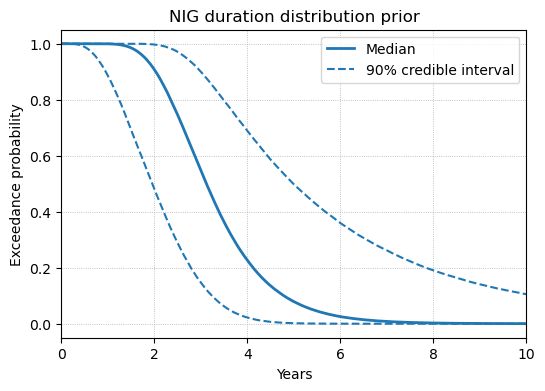

In [49]:
mu_target, sigma_target, resid_vec, resid_norm = calibrate_lognormal_three_bins(mean_target=3.43,
                                                                                t1=2, t2=3,
                                                                                p_lt_t1=1/6, p_between=1/3)
print(f"LogNormal (mean≈3.43, P[2≤X≤3]=1/3): mu={mu_target:.4f}, sigma={sigma_target:.4f}")
print(f"Residuals: {resid_vec}")

mu0, kappa0, alpha0, beta0 = calibrate_nig_prior(mu_target, sigma_target,
                                                 kappa0=2, # Minimal information assumption
                                                 alpha0=2 # Minimal information assumption
                                                 )
print(f"NIG prior: (sigma^2 ~ IG({alpha0:.2f}, {beta0:.2f}, ~ N({mu0:.2f}, sigma^2 / {kappa0:.2f})))")

plot_survival_from_nig(mu0, kappa0, alpha0, beta0)

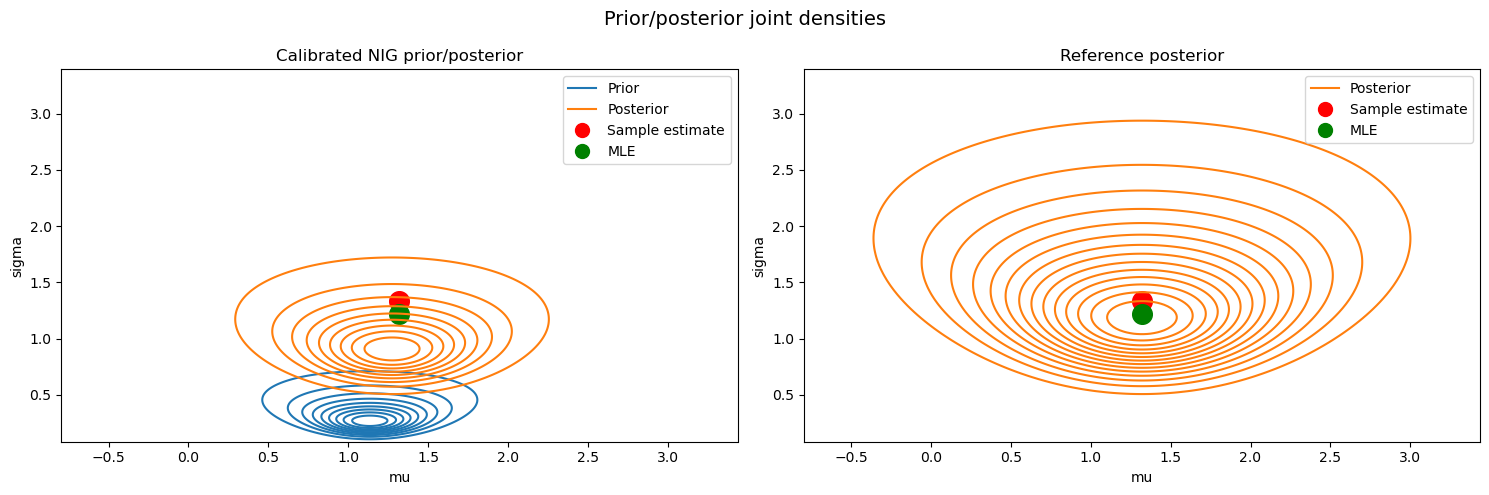

In [51]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Prior/posterior joint densities', fontsize=14)

# Get true parameters from data
sample_mu = np.log(duration_data).mean()
sample_sigma = np.log(duration_data).std()

# 2. Calibrated NIG prior using parameters from above
cal_nig_updater = LogNormalBayesianUpdater(prior_type='NIG', mu0=mu0, kappa0=kappa0, alpha0=alpha0, beta0=beta0)
cal_nig_updater.update(duration_data)
cal_prior = cal_nig_updater.get_prior_grid()
cal_post = cal_nig_updater.get_posterior_grid()
cal_prior['type'] = 'Prior'
cal_post['type'] = 'Posterior'
nig_df = pd.concat([cal_prior, cal_post])

# 3. Reference prior
ref_updater = LogNormalBayesianUpdater(prior_type='reference')
ref_updater.update(duration_data)
ref_post = ref_updater.get_posterior_grid()

# Plot results
titles = ['Calibrated NIG prior/posterior', 'Reference posterior']
dfs = [nig_df, ref_post]

# Get overall min/max for consistent axes
all_mu = pd.concat([df['mu'] for df in dfs])
all_sigma = pd.concat([df['sigma'] for df in dfs])
mu_min, mu_max = all_mu.min(), all_mu.max()
sigma_min, sigma_max = all_sigma.min(), all_sigma.max()

# Fit MLE lognormal
mle_params = scipy.stats.lognorm.fit(duration_data, floc=0)
mle_sigma, _, mle_mu = mle_params  # fit returns (s, loc, scale)
mle_mu = np.log(mle_mu)  # Convert scale to mu
# Define colors for prior and posterior
prior_color = sns.color_palette()[0]  # First color in default palette
post_color = sns.color_palette()[1]   # Second color in default palette

for i, (title, df) in enumerate(zip(titles, dfs)):
    ax = axes[i]
    if i == 0:  # For NIG priors
        sns.kdeplot(
            data=df,
            x='mu',
            y='sigma', 
            weights='density',
            hue='type',
            fill=False,
            levels=10,
            common_norm=False,
            ax=ax,
            bw_adjust=1.0,
            cut=0,
            palette=[prior_color, post_color],  # Set consistent colors
            label='Prior/Posterior'
        )
    else:  # For reference prior
        sns.kdeplot(
            data=df,
            x='mu',
            y='sigma',
            weights='density', 
            fill=False,
            levels=15,
            ax=ax,
            bw_adjust=1.0,
            cut=0,
            color=post_color,  # Use posterior color
            label='Posterior'
        )
    
    # Add true value point
    ax.scatter(sample_mu, sample_sigma, color='red', s=200, label='Sample estimate')
    ax.scatter(mle_mu, mle_sigma, color='green', s=200, label='MLE')
    
    ax.set_title(title)
    
    # Set consistent axis limits
    ax.set_xlim(mu_min, mu_max)
    ax.set_ylim(sigma_min, sigma_max)
    
    # Add legend with all elements
    if i == 0:
        handles = [
            plt.Line2D([], [], color=prior_color, label='Prior'),
            plt.Line2D([], [], color=post_color, label='Posterior'),
            plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Sample estimate'),
            plt.Line2D([], [], color='green', marker='o', linestyle='None', markersize=10, label='MLE')
        ]
    else:
        handles = [
            plt.Line2D([], [], color=post_color, label='Posterior'),
            plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Sample estimate'),
            plt.Line2D([], [], color='green', marker='o', linestyle='None', markersize=10, label='MLE')
        ]
    ax.legend(handles=handles)

plt.tight_layout()
plt.show()

In [53]:
duration_updater = cal_nig_updater

In [ ]:
# ─── 0.  CONSTANTS (updated) ──────────────────────────────────────────────
T_YEARS_10M   = 6.0 # 2020 to 2025 inclusive
T_YEARS_25M   = 7.0 # 2025 to 2031 inclusive
X_10M         = 12.5
X_25M         = 31.0

# Targets: (central, 5%, 95%) for each
TARGET_10M = (0.10, 0.05, 0.25)
TARGET_25M = (0.05, 0.03, 0.12)

N_SIM     = 100_000              # MC draws per objective evaluation
R_RESTART = 10                   # optimiser restarts for uniqueness check


# ─── 1.  GPD SURVIVAL AT THRESHOLD ─────────────────────────────────────────
def gpd_tail(x, xi, sigma, mu=0.01):
    """Survival function  P(X ≥ x | ξ, σ)  for ξ ≠ 0."""
    # Handle case where xi is close to zero by using exponential limit
    z = (x-mu)/sigma
    xi_small = np.abs(xi) < 1e-4
    t = np.zeros_like(z)
    t[xi_small] = np.exp(-z[xi_small])  # Exponential limit as xi->0
    t[~xi_small] = np.power(1 + xi[~xi_small] * z[~xi_small], -1.0 / xi[~xi_small])
    
    if np.any(np.isnan(t)):
        print("Found NaN values at:")
        print("x", x[np.isnan(t)])
        print("xi:", xi[np.isnan(t)])
        print("sigma", sigma[np.isnan(t)])
        print("z:", z[np.isnan(t)])
        print("1 + xi*z:", 1 + xi[np.isnan(t)]*z[np.isnan(t)])
    # print(t[xi_small])
    # print(t[~xi_small])
    
    return np.where(t > 0, t, 0.0)


U_lam, U_sig, U_xi, U_dur = np.random.default_rng(0).random((4, N_SIM))


# --- 1.5 Draw durations ------------------------
def draw_intensity_thresholds(updater, n_samples, rng=None):
    """
    Draw intensity thresholds for 25M deaths using uncertain duration
    """
    rng = np.random.default_rng(rng)
    
    mu_samples, sigma_samples = updater.sample_posterior(n_samples=n_samples, rng=rng)
    durations = scipy.stats.lognorm(s=sigma_samples, scale=np.exp(mu_samples)).ppf(U_dur)
    intensity_thresholds = X_25M / durations
    return intensity_thresholds


# ← new: stochastic intensity thresholds for the 25M-death constraint
x_25m_draws = draw_intensity_thresholds(duration_updater, N_SIM, rng=0)

# ─── 2.  PRIOR-PREDICTIVE MOMENT FUNCTION ─────────────────────────────────
def prior_prob(theta):
    alpha, beta, mu_sig, tau_sig, mu_xi, sd_xi = theta

    lam   = gamma(a=alpha, scale=beta).ppf(U_lam)
    sigma = lognorm(s=tau_sig, scale=np.exp(mu_sig)).ppf(U_sig)
    a = (0  - mu_xi) / sd_xi
    b = (5  - mu_xi) / sd_xi
    xi    = truncnorm(a=a, b=b, loc=mu_xi, scale=sd_xi).ppf(U_xi)

    def event_prob(x_thresh, T_window):
        p_arrival  = 1.0 - np.exp(-lam * T_window)
        p_severity = gpd_tail(x_thresh, xi, sigma)
        return p_arrival * p_severity
    
    p_10m = event_prob(X_10M, T_YEARS_10M)
    p_25m = event_prob(x_25m_draws, T_YEARS_25M)  # ← vector of thresholds

    return (
        p_10m.mean(), *np.quantile(p_10m, [0.05, 0.95]),
        p_25m.mean(), *np.quantile(p_25m, [0.05, 0.95])
    )


# ─── 3.  RESIDUALS FOR OPTIMISER ───────────────────────────────────────────
def residuals(theta, rng):
    m10, q10lo, q10hi, m25, q25lo, q25hi = prior_prob(theta, rng)

    return np.sum(np.power([
        (m10   - TARGET_10M[0]),
        (q10lo - TARGET_10M[1]),
        (q10hi - TARGET_10M[2]),
        (m25   - TARGET_25M[0]),
        (q25lo - TARGET_25M[1]),
        (q25hi - TARGET_25M[2])
    ], 2))


# ─── 4.  CALIBRATION WRAPPER ──────────────────────────────────────────────
def calibrate_once(seed, bounds):
    rng = np.random.default_rng(seed)

    # Initial guesses based on typical GPD parameters and target probabilities
    theta0 = np.array([1.5, 0.02,    # α, β  (λ mean ≈0.03 events/year)
                       2.0, 0.5,     # μσ ≈ e^2 ≈7.4, τσ=0.5 (wider spread)
                       0.2, 1.0])    # μξ>0 for heavy tail, moderate σξ

    result = minimize(residuals, theta0,
                      args=(rng,),
                      bounds=bounds,
											method='L-BFGS-B',
                      options=dict(maxiter=500, disp=True),                                        
                      )
    return result.x, result.fun, result.success

bounds = (
  	(0.1, 10),    # α > 0
		(1e-4, 1),     # β > 0 
		(-5, 5),       # μσ (unrestricted)
		(0.01, 5),     # τσ > 0
		(-0.5, 4),       # μξ (allow slight negative)
		(0.01, 5)    # σξ > 0
)

sols = []
for k in range(R_RESTART):
		theta, cost, ok = calibrate_once(seed=89 + k, bounds=bounds)
		status = "OK " if ok else "FAIL"
		print(f"[restart {k}] {status} cost={cost:.2e}  theta={theta}")
		sols.append(theta)

# Create a pandas DataFrame of solutions
df = pd.DataFrame(sols, columns=['α', 'β', 'μσ', 'τσ', 'μξ', 'σξ'])
df.index.name = 'Restart'
display(df)

In [111]:
# ─── 1.  GPD SURVIVAL AT THRESHOLD ─────────────────────────────────────────
def gpd_tail(x, xi, sigma, mu=0.01, verbose=False):
    """Survival function  P(X ≥ x | ξ, σ)  for ξ ≠ 0."""
    # Handle case where xi is close to zero by using exponential limit
    z = (x-mu)/sigma
    xi_small = np.abs(xi) < 1e-4
    t = np.zeros_like(z)
    t[xi_small] = np.exp(-z[xi_small])  # Exponential limit as xi->0
    t[~xi_small] = np.power(1 + xi[~xi_small] * z[~xi_small], -1.0 / xi[~xi_small])
    
    if np.any(np.isnan(t)) and verbose:
        print("Found NaN values at:")
        print("xi:", xi[np.isnan(t)])
        print("sigma", sigma[np.isnan(t)])
        print("z:", z[np.isnan(t)])
        print("1 + xi*z:", 1 + xi[np.isnan(t)]*z[np.isnan(t)])
        print("x:", x if np.isscalar(x) else x[np.isnan(t)])
    # print(t[xi_small])
    # print(t[~xi_small])
    
    return np.where(t > 0, t, 0.0)

In [124]:
def transform(theta):
    α, β, μσ, τσ, μξ, σξ = theta
    return np.array([
        np.log(α), np.log(β), μσ, np.log(τσ), μξ, np.log(σξ)
    ])

def inverse_transform(v):
    lα, lβ, μσ, lτσ, μξ, lσξ = v
    return np.array([
        np.exp(lα), np.exp(lβ), μσ, np.exp(lτσ), μξ, np.exp(lσξ)
    ])

# ---------- hyper-parameters -----------------------------------------------
N_SIM      = 10_000
N_STARTS   = 5 # different theta0 per seed
SEEDS_U    = [0, 11, 22, 33] # independent CRN seeds to try
SEEDS_OPT  = [91] # optimiser RNGs (finite-diff noise control)

bounds = np.array([
    (0.1, 10),      # α
    (1e-4, 1),      # β
    (-5, 5),        # μσ
    (0.01, 5),      # τσ
    (-0.5, 4),      # μξ
    (0.01, 5)       # σξ
])
lo, hi = bounds.T


# --- 1.5 Draw durations ------------------------
def draw_intensity_thresholds(updater, n_samples, rng=None):
    """
    Draw intensity thresholds for 25M deaths using uncertain duration
    """
    rng = np.random.default_rng(rng)
    
    mu_samples, sigma_samples = updater.sample_posterior(n_samples=n_samples, rng=rng)
    durations = scipy.stats.lognorm.rvs(s=sigma_samples, scale=np.exp(mu_samples))
    intensity_thresholds = X_25M / durations
    intensity_thresholds[intensity_thresholds < 0.01] = 0.01
    return intensity_thresholds


def make_prior_and_residuals(U_seed, verbose=False):
    "Return deterministic prior_prob() and residuals() tied to one CRN set."
    rngU = np.random.default_rng(U_seed)
    U_lam, U_sig, U_xi, U_dur = rngU.random((4, N_SIM))
    
    mu_samples, sigma_samples = duration_updater.sample_posterior(n_samples=N_SIM, rng=rngU)
    durations = scipy.stats.lognorm(s=sigma_samples, scale=np.exp(mu_samples)).ppf(U_dur)
    x25_draws = X_25M / durations
    x25_draws[x25_draws < 0.01] = 0.01

    def prior_prob(theta):
        α, β, μσ, τσ, μξ, σξ = theta
        lam = gamma(a=α, scale=β).ppf(U_lam)
        sigma = lognorm(s=τσ, scale=np.exp(μσ)).ppf(U_sig)
        # Normalize truncation bounds by scale and location
        a_norm = (0 - μξ) / σξ  # Transform lower bound 0 to standard normal
        b_norm = (5 - μξ) / σξ  # Transform upper bound 5 to standard normal
        xi = truncnorm(a=a_norm, b=b_norm, loc=μξ, scale=σξ).ppf(U_xi)

        def event_prob(x_thresh, T_win):
            p_arrival  = 1 - np.exp(-lam * T_win)
            p_severity = gpd_tail(x_thresh, xi, sigma, verbose=verbose)
            return p_arrival * p_severity

        p10  = event_prob(X_10M,  T_YEARS_10M)
        p25  = event_prob(x25_draws, T_YEARS_25M)
        return ( p10.mean(), *np.quantile(p10,[.05,.95]),
                 p25.mean(), *np.quantile(p25,[.05,.95]) )

    def residuals(theta):
        m10,q10lo,q10hi,m25,q25lo,q25hi = prior_prob(theta)
        return np.sum(( np.array([m10,q10lo,q10hi,m25,q25lo,q25hi])
                        - np.array([*TARGET_10M,*TARGET_25M]) )**2)
    
    def residuals_transformed(v):
        theta = inverse_transform(v)
        return residuals(theta)
    
    return prior_prob, residuals_transformed, transform


def random_theta0(rng):
    "Draw one starting point *uniformly* inside bounds."
    return rng.uniform(lo, hi)

records = []

for seedU in tqdm(SEEDS_U):
    prior_prob, residuals_transformed, transform_fn = make_prior_and_residuals(seedU, verbose=False)

    for j in range(N_STARTS):
        rng = np.random.default_rng(seedU * 100 + j)
        theta0 = random_theta0(rng)
        v0 = transform_fn(theta0)

        for seedOpt in SEEDS_OPT:
            res = minimize(
                residuals_transformed, v0, method='L-BFGS-B',
                options=dict(maxiter=500)
            )
            final_theta = inverse_transform(res.x)
            records.append(dict(
                CRN_seed = seedU,
                start_id = j,
                opt_seed = seedOpt,
                success  = res.success,
                cost     = res.fun,
                **dict(zip(['α', 'β', 'μσ', 'τσ', 'μξ', 'σξ'], final_theta))
            ))

df = pd.DataFrame(records)

  0%|          | 0/4 [00:00<?, ?it/s]c:\Users\squaade\scoop\apps\anaconda3\current\App\envs\pandemic_model\Lib\site-packages\scipy\stats\_continuous_distns.py:6851: RuntimeWarning: overflow encountered in exp
  return np.exp(s * _norm_ppf(q))
C:\Users\squaade\AppData\Local\Temp\ipykernel_26196\2486966536.py:5: RuntimeWarning: divide by zero encountered in divide
  z = (x-mu)/sigma
 25%|██▌       | 1/4 [00:41<02:04, 41.65s/it]


KeyboardInterrupt: 

In [123]:
df

,CRN_seed,start_id,opt_seed,success,cost,α,β,μσ,τσ,μξ,σξ
0,0,0,91,True,0.019027,6.407111,0.285951,-4.563815,0.221512,3.154536,4.563119
1,0,1,91,True,0.020799,5.167161,0.950740,-5.000000,1.788877,1.921738,4.999950
2,0,2,91,True,0.020442,2.331384,0.009511,2.429031,0.204809,2.181488,3.645519
3,0,3,91,True,0.020713,0.423822,0.028623,2.839479,2.831790,-0.084617,2.156218
4,0,4,91,True,0.021259,9.436187,0.510633,-4.498032,1.666185,1.231278,1.866237
5,11,0,91,True,0.024379,1.827379,0.014053,1.769688,0.274856,0.420442,2.727754
6,11,1,91,True,0.018001,8.874284,0.002465,2.983274,4.487351,1.627106,2.763412
7,11,2,91,True,0.015867,6.183007,0.002916,5.000000,1.709731,1.990049,0.527619
8,11,3,91,True,0.019714,2.286751,0.671381,-4.344958,0.478425,2.513685,2.694059
9,11,4,91,True,0.020822,0.818749,0.020276,1.550973,3.720069,1.703272,0.204965
